<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/02_construction_data_preparation_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DADS5001 Mini Project
## การเตรียมข้อมูลโครงการจ้างก่อสร้าง ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 **สะสมถึงวันที่ 30 กรกฎาคม 2569** ไม่ใช่ข้อมูลเต็มปี Notebook อ่านไฟล์ต้นทาง 8 ไฟล์แบบแบ่งส่วน และสกัดรายการประเภท `จ้างก่อสร้าง`

ไฟล์ผลลัพธ์ยังเก็บโครงการก่อสร้างทุกวิธีและทุกวงเงิน เพื่อใช้เป็นประชากรอ้างอิง ส่วน Notebook 03–04 จะกำหนดกลุ่มศึกษาหลักเป็น **โครงการวิธีเฉพาะเจาะจงที่มีวงเงินไม่เกิน 500,000 บาท**

ใช้ `รหัสโครงการ` เป็นหน่วยวิเคราะห์ระดับโครงการ และเก็บทุกแถวสำหรับตรวจรายละเอียดสัญญา ผู้รับจ้าง และ Joint Venture (JV)

> ขั้นตอนนี้เตรียมและตรวจสอบข้อมูล ยังไม่ใช้รูปแบบที่พบตัดสินความผิด


In [30]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from pathlib import Path

import pandas as pd

# ดาวน์โหลดฟอนต์ TH Sarabun New
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# เพิ่มฟอนต์ให้ Matplotlib
fm.fontManager.addfont(
    'thsarabunnew-webfont.ttf'
)

# กำหนดฟอนต์เริ่มต้นสำหรับ Matplotlib และ Seaborn
mpl.rc(
    'font',
    family='TH Sarabun New'
)
mpl.rcParams['axes.unicode_minus'] = False

sns.set_theme(
    style='whitegrid',
    font='TH Sarabun New'
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

base_dir = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/egp-contract/2569'
)

processed_dir = base_dir.parent / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

csv_files = sorted(base_dir.glob('*.csv'))
construction_path = processed_dir / 'construction_contracts_2569.csv'

project_directory = base_dir.parents[3]
figure_directory = project_directory / 'figure'
figure_directory.mkdir(parents=True, exist_ok=True)

print(f'CSV files found: {len(csv_files)}')
print(f'Construction output: {construction_path}')
print(f'Figure directory: {figure_directory}')


CSV files found: 8
Construction output: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contracts_2569.csv
Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure


## 1. สำรวจโครงสร้างข้อมูลเบื้องต้น

เริ่มจากอ่านข้อมูลตัวอย่างจากไฟล์แรก เพื่อทำความเข้าใจโครงสร้าง
ชื่อคอลัมน์ และลักษณะข้อมูล ก่อนประมวลผลไฟล์ทั้งหมด

In [32]:
sample_data = pd.read_csv(
    csv_files[0],
    nrows=5
)

print(f'Sample file: {csv_files[0].name}')
print(f'Number of columns: {sample_data.shape[1]}')

display(sample_data)

Sample file: 2569-egp-contract-1.csv
Number of columns: 28


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา
0,1,68099218030,ประกวดราคาเช่ารถโดยสารประจำทางปรับอากาศพลังงาน...,เช่า,องค์การขนส่งมวลชนกรุงเทพ,องค์การขนส่งมวลชนกรุงเทพ (ขสมก.) กรุงเทพฯ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,18 พ.ย. 68,15355600000,"15,326,737,242.00",14905000000,2569,29 ม.ค. 69,กรุงเทพมหานคร,พระนคร,พระบรมมหาราชวัง,ระหว่างดำเนินการ,NaN,NaN,NaN,0365529000042,บริษัท นครชัยแอร์ จำกัด,ช.16/2569,29 ม.ค. 69,29 ม.ค. 76,14905000000,ระหว่างดำเนินการ
1,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,4000000000,"4,000,000,000.00",3997800000,2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,3997800000,ระหว่างดำเนินการ
2,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,4083120000,"3,872,008,000.00",3870550927,2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,3870550927,ระหว่างดำเนินการ
3,4,68099239630,ซื้อเครื่องบินลำเลียงสนับสนุนปฏิบัติการทางเรือ...,ซื้อ,กองทัพเรือ,กองทัพเรือ (สยป.ทร/งานโครงการจัดหายุทโธปกรณ์หล...,เฉพาะเจาะจง,วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,-,3770000000,"3,769,999,987.00",3769913800,2569,27 พ.ค. 69,กรุงเทพมหานคร,บางกอกใหญ่,วัดอรุณ,ระหว่างดำเนินการ,NaN,NaN,NaN,899680900xxxx,บริษัท Airbus Defence and Space S.A.U,AIR-ุ6873-01,27 พ.ค. 69,26 พ.ค. 73,3769913800,ระหว่างดำเนินการ
4,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,3300000000,"3,407,005,257.46",3285000000,2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,3285000000,ระหว่างดำเนินการ


In [33]:
for position, column in enumerate(
    sample_data.columns,
    start=1
):
    print(f'{position:02d}. {column}')

01. ลำดับ
02. รหัสโครงการ
03. ชื่อโครงการจัดซื้อจัดจ้าง
04. ชื่อประเภทโครงการ
05. ชื่อหน่วยงาน
06. ชื่อหน่วยงานย่อย
07. ชื่อวิธีการจัดซื้อจัดจ้าง
08. ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง
09. วันที่ประกาศจัดซื้อจัดจ้าง
10. วงเงินงบประมาณ (บาท)
11. ราคากลาง (บาท)
12. ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)
13. ปีงบประมาณ
14. วันที่เกิดรายการ
15. จังหวัด
16. เขต/อำเภอ
17. แขวง/ตำบล
18. สถานะโครงการ
19. พิกัดของโครงการ
20. ละติจูดของโครงการ
21. ลองจิจูดของโครงการ
22. เลขประจำตัวนิติบุคคล 13 หลัก
23. ชื่อผู้ชนะการเสนอราคา
24. เลขที่สัญญา
25. วันที่ลงนามในสัญญา
26. วันที่สิ้นสุดสัญญา
27. วงเงินงบประมาณในสัญญา (บาท)
28. สถานะสัญญา


## 2. ภาพรวมประเภทโครงการและการสกัดข้อมูล

อ่านข้อมูลแบบแบ่งส่วนเพื่อ:

1. นับจำนวนแถวตามประเภทโครงการ
2. สกัดรายการ `จ้างก่อสร้าง` ทุกคอลัมน์
3. เก็บชื่อไฟล์ต้นทางเพื่อให้ตรวจสอบย้อนกลับได้

ส่วนนี้ใช้คำว่า “จำนวนรายการ” เพราะหนึ่งโครงการอาจมีหลายสัญญา ผู้รับจ้าง หรือแถวสมาชิก Joint Venture (JV)


In [34]:
project_type_column = 'ชื่อประเภทโครงการ'
chunk_size = 100_000

type_counts_list = []
processing_results = []

first_write = True

for file_number, file_path in enumerate(
    csv_files,
    start=1
):
    print(
        f'Processing {file_number}/{len(csv_files)}: '
        f'{file_path.name}'
    )

    total_rows = 0
    construction_rows = 0

    reader = pd.read_csv(
        file_path,
        chunksize=chunk_size,
        low_memory=False
    )

    for chunk in reader:
        chunk.columns = chunk.columns.str.strip()
        total_rows += len(chunk)

        project_type = (
            chunk[project_type_column]
            .astype('string')
            .str.strip()
            .fillna('ไม่ระบุ')
        )

        type_counts_list.append(
            project_type.value_counts()
        )

        construction_chunk = chunk.loc[
            project_type.eq('จ้างก่อสร้าง')
        ].copy()

        construction_rows += len(
            construction_chunk
        )

        if not construction_chunk.empty:
            construction_chunk['source_file'] = (
                file_path.name
            )

            construction_chunk.to_csv(
                construction_path,
                mode='w' if first_write else 'a',
                header=first_write,
                index=False,
                encoding='utf-8-sig'
            )

            first_write = False

    processing_results.append({
        'file_name': file_path.name,
        'total_rows': total_rows,
        'construction_rows': construction_rows
    })

    print(
        f'  Total rows: {total_rows:,} | '
        f'Construction rows: {construction_rows:,}'
    )

processing_summary = pd.DataFrame(
    processing_results
)

project_type_counts = (
    pd.concat(
        type_counts_list,
        axis=1
    )
    .fillna(0)
    .sum(axis=1)
    .astype('int64')
    .sort_values(ascending=False)
    .rename('record_count')
    .reset_index()
    .rename(
        columns={
            'index': project_type_column
        }
    )
)

total_records = (
    processing_summary['total_rows'].sum()
)

total_construction_records = (
    processing_summary[
        'construction_rows'
    ].sum()
)

construction_pct = (
    total_construction_records
    / total_records
    * 100
)

display(processing_summary)

print(f'Total records: {total_records:,}')
print(
    f'Construction records: '
    f'{total_construction_records:,}'
)
print(
    f'Construction share: '
    f'{construction_pct:.2f}%'
)
print(f'Output file: {construction_path}')

Processing 1/8: 2569-egp-contract-1.csv
  Total rows: 514,660 | Construction rows: 136,569
Processing 2/8: 2569-egp-contract-2.csv
  Total rows: 504,966 | Construction rows: 30,844
Processing 3/8: 2569-egp-contract-3.csv
  Total rows: 502,705 | Construction rows: 7,603
Processing 4/8: 2569-egp-contract-4.csv
  Total rows: 502,089 | Construction rows: 3,013
Processing 5/8: 2569-egp-contract-5.csv
  Total rows: 501,672 | Construction rows: 1,169
Processing 6/8: 2569-egp-contract-6.csv
  Total rows: 501,482 | Construction rows: 585
Processing 7/8: 2569-egp-contract-7.csv
  Total rows: 501,038 | Construction rows: 235
Processing 8/8: 2569-egp-contract-8.csv
  Total rows: 436,312 | Construction rows: 61


,file_name,total_rows,construction_rows
0,2569-egp-contract-1.csv,514660,136569
1,2569-egp-contract-2.csv,504966,30844
2,2569-egp-contract-3.csv,502705,7603
3,2569-egp-contract-4.csv,502089,3013
4,2569-egp-contract-5.csv,501672,1169
5,2569-egp-contract-6.csv,501482,585
6,2569-egp-contract-7.csv,501038,235
7,2569-egp-contract-8.csv,436312,61


Total records: 3,964,924
Construction records: 180,079
Construction share: 4.54%
Output file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contracts_2569.csv


In [35]:
# ตรวจยืนยันผลการประมวลผลกับข้อมูลชุดที่ใช้ในโครงการ
expected_file_count = 8
expected_total_records = 3_964_924
expected_construction_records = 180_079

assert len(csv_files) == expected_file_count, (
    f'Expected {expected_file_count} source files, '
    f'but found {len(csv_files)}'
)
assert total_records == expected_total_records, (
    f'Expected {expected_total_records:,} source rows, '
    f'but found {total_records:,}'
)
assert total_construction_records == expected_construction_records, (
    f'Expected {expected_construction_records:,} construction rows, '
    f'but found {total_construction_records:,}'
)
assert construction_path.exists(), (
    f'Output file was not created: {construction_path}'
)

print('Validation passed:')
print(f'- Source files: {len(csv_files)}')
print(f'- Source rows: {total_records:,}')
print(f'- Construction rows: {total_construction_records:,}')
print(f'- Output file exists: {construction_path.exists()}')

Validation passed:
- Source files: 8
- Source rows: 3,964,924
- Construction rows: 180,079
- Output file exists: True


### ผลการประมวลผล

ข้อมูลต้นทางปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ประกอบด้วย 8 ไฟล์ รวมทั้งหมด
3,964,924 รายการ

เมื่อกรองด้วย `ชื่อประเภทโครงการ = 'จ้างก่อสร้าง'`
พบข้อมูลจำนวน 180,079 รายการ คิดเป็น 4.54% ของข้อมูลทั้งหมด
และได้บันทึกข้อมูลกลุ่มดังกล่าวเป็นไฟล์
`construction_contracts_2569.csv` สำหรับใช้วิเคราะห์ต่อ

จำนวนดังกล่าวเป็นจำนวนแถวหรือรายการในข้อมูล ไม่ใช่จำนวนโครงการ
ที่ไม่ซ้ำ เนื่องจากหนึ่งโครงการอาจมีมากกว่าหนึ่งสัญญา
หรือมากกว่าหนึ่งผู้ชนะการเสนอราคา

In [36]:
project_type_counts['record_pct'] = (
    project_type_counts['record_count']
    .div(
        project_type_counts[
            'record_count'
        ].sum()
    )
    .mul(100)
)

display(project_type_counts)

,ชื่อประเภทโครงการ,record_count,record_pct
0,ซื้อ,2493989,62.90
1,จ้างทำของ/จ้างเหมาบริการ,1242589,31.34
2,จ้างก่อสร้าง,180079,4.54
3,เช่า,44985,1.13
4,จ้างที่ปรึกษา,1672,0.04
5,จ้างออกแบบ,1388,0.04
6,จ้างควบคุมงาน,171,0.00
7,จ้างออกแบบและควบคุมงานก่อสร้าง,35,0.00
8,-,16,0.00


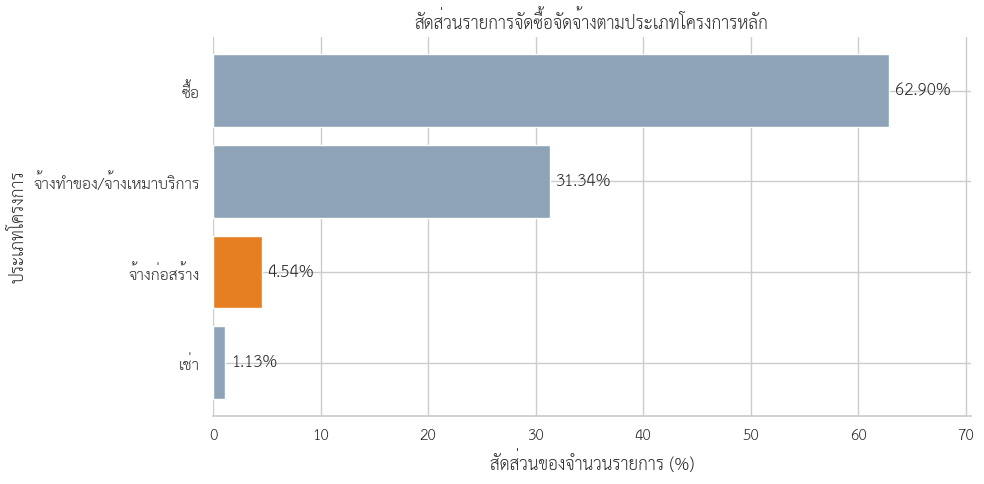

Figure saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig02_01_share_of_procurement_records.png


In [37]:
major_types = (
    project_type_counts
    .head(4)
    .sort_values('record_pct', ascending=True)
    .copy()
)

colors = [
    '#E67E22'
    if project_type == 'จ้างก่อสร้าง'
    else '#8FA3B8'
    for project_type
    in major_types['ชื่อประเภทโครงการ']
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    major_types['ชื่อประเภทโครงการ'],
    major_types['record_pct'],
    color=colors
)

ax.bar_label(
    bars,
    labels=[
        f'{value:.2f}%'
        for value in major_types['record_pct']
    ],
    padding=4
)

ax.set_title('สัดส่วนรายการจัดซื้อจัดจ้างตามประเภทโครงการหลัก')
ax.set_xlabel('สัดส่วนของจำนวนรายการ (%)')
ax.set_ylabel('ประเภทโครงการ')
ax.set_xlim(0, major_types['record_pct'].max() * 1.12)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()

figure_path = figure_directory / 'fig02_01_share_of_procurement_records.png'
fig.savefig(figure_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'Figure saved: {figure_path}')


### ผลการเลือกขอบเขตงานก่อสร้าง

สัดส่วนที่แสดงเป็นสัดส่วนของจำนวนแถว ไม่ใช่สัดส่วนจำนวนโครงการหรือมูลค่า ข้อมูลประเภทจ้างก่อสร้างถูกบันทึกเป็น `construction_contracts_2569.csv` เพื่อใช้ต่อโดยไม่ต้องอ่านไฟล์ต้นทางทั้งหมดซ้ำ

ภาพนี้ใช้ยืนยันที่มาของการเลือกประเภทงานก่อสร้างและเชื่อมกับส่วนภาพรวมของโครงการ ไม่ใช้เป็น Indicator


## 3. ตรวจสอบชุดข้อมูลจ้างก่อสร้าง

ตรวจจำนวนแถว คอลัมน์ รหัสโครงการ แถวซ้ำ และโครงการที่ปรากฏหลายแถว ก่อนส่งต่อไปสร้างข้อมูลระดับโครงการและระดับสัญญา


In [38]:
construction_data = pd.read_csv(
    construction_path,
    low_memory=False
)

print(
    f'Shape: '
    f'{construction_data.shape}'
)

display(
    construction_data.head()
)

Shape: (180079, 29)


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,"4,000,000,000.00","4,000,000,000.00","3,997,800,000.00",2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,"4,083,120,000.00","3,872,008,000.00","3,870,550,927.00",2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
2,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,"3,300,000,000.00","3,407,005,257.46","3,285,000,000.00",2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,"3,285,000,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
3,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,28 พ.ย. 68,"3,370,500,000.00","3,285,232,000.00","3,282,800,000.00",2569,29 มิ.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"LINESTRING(100.62686920166 13.926236380743,100...",13.88,100.60,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,MP8-3402-ABL,29 มิ.ย. 69,10 ธ.ค. 72,"3,282,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
4,7,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงข...,จ้างก่อสร้าง,การประปาส่วนภูมิภาค,กองจัดหา การประปาส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,16 ก.ค. 68,"3,498,760,900.00","3,498,752,340.00","3,250,900,000.00",2569,20 พ.ย. 68,กรุงเทพมหานคร,หลักสี่,ตลาดบางเขน,ระหว่างดำเนินการ,POINT(98.5303660281 8.4326626992),8.43,98.53,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,กจห.123/2568,20 พ.ย. 68,23 เม.ย. 71,"3,250,900,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv


In [39]:
validation_summary = pd.Series({
    'Rows': len(construction_data),
    'Columns': construction_data.shape[1],
    'Unique project IDs': (
        construction_data[
            'รหัสโครงการ'
        ].nunique()
    ),
    'Unique contract number labels (not contract count)': (
        construction_data[
            'เลขที่สัญญา'
        ].nunique()
    ),
    'Missing project IDs': (
        construction_data[
            'รหัสโครงการ'
        ].isna().sum()
    ),
    'Missing contract numbers': (
        construction_data[
            'เลขที่สัญญา'
        ].isna().sum()
    ),
    'Exact duplicate rows': (
        construction_data
        .drop(columns='source_file')
        .duplicated()
        .sum()
    )
})

display(
    validation_summary.to_frame(
        name='value'
    )
)

display(
    construction_data[
        'ชื่อประเภทโครงการ'
    ].value_counts(
        dropna=False
    )
)

,value
Rows,180079
Columns,29
Unique project IDs,178978
Unique contract number labels (not contract count),32949
Missing project IDs,0
Missing contract numbers,0
Exact duplicate rows,0


,count
ชื่อประเภทโครงการ,
จ้างก่อสร้าง,180079


In [40]:
project_row_counts = (
    construction_data[
        'รหัสโครงการ'
    ]
    .value_counts()
)

print(
    'Projects with more than one row:',
    (project_row_counts > 1).sum()
)

print(
    'Maximum rows per project:',
    project_row_counts.max()
)

print(
    '\nMost frequent contract number labels '
    '(not a count of unique contracts):'
)

display(
    construction_data[
        'เลขที่สัญญา'
    ]
    .value_counts(
        dropna=False
    )
    .head(10)
)

repeated_project_ids = (
    project_row_counts.loc[
        project_row_counts > 1
    ]
    .head(3)
    .index
)

repeated_project_sample = (
    construction_data.loc[
        construction_data[
            'รหัสโครงการ'
        ].isin(
            repeated_project_ids
        ),
        [
            'รหัสโครงการ',
            'ชื่อโครงการจัดซื้อจัดจ้าง',
            'ชื่อผู้ชนะการเสนอราคา',
            'เลขที่สัญญา',
            'วงเงินงบประมาณในสัญญา (บาท)'
        ]
    ]
    .sort_values(
        [
            'รหัสโครงการ',
            'เลขที่สัญญา'
        ]
    )
    .head(20)
)

display(repeated_project_sample)

Projects with more than one row: 524
Maximum rows per project: 15

Most frequent contract number labels (not a count of unique contracts):


,count
เลขที่สัญญา,
1/2569,8040
2/2569,5518
3/2569,5112
4/2569,4853
5/2569,4502
6/2569,4203
7/2569,3922
10/2569,3753
8/2569,3713


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท)
14,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,บริษัท มินเซนแมชีนเนอรี่ จำกัด,สญ. 41/2569,"178,540,949.00"
15,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,กิจการค้าร่วม กิจชัย,"สญ. 42/2569, 44/2569, 52/2569","439,680,510.00"
16,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,บริษัทจำกัด บริษัท สุชัยธนา จำกัด(สัญญากิจการค...,"สญ. 42/2569, 44/2569, 52/2569","131,904,153.00"
17,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,ห้างหุ้นส่วนจำกัด ห้างหุ้นส่วนจำกัด สิทธิยนต์(...,"สญ. 42/2569, 44/2569, 52/2569","307,776,357.00"
18,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,บริษัท ล็อกซเล่ย์ พร็อพเพอร์ตี้ ดีเวลลอปเม้นท์...,สญ. 43/2569,"119,376,048.00"
19,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,กิจการค้าร่วมประจักษ์พีเจ,"สญ. 45/2569, 51/2569","201,372,900.00"
20,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,บริษัทจำกัด บริษัท พีเจ โซลาร์เทค (ประเทศไทย) ...,"สญ. 45/2569, 51/2569","98,672,721.00"
21,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,ห้างหุ้นส่วนจำกัด ห้างหุ้นส่วนจำกัด ประจักษ์พิ...,"สญ. 45/2569, 51/2569","102,700,179.00"
22,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,บริษัท รุ่งวิจิตรการช่าง จำกัด,สญ. 46/2569,"199,676,200.00"
23,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,บริษัท โกลบอล วอเตอร์ ไลฟ์ จำกัด,สญ. 47/2569,"124,242,200.00"


In [41]:
# Confirm that the study scope can be reproduced from project-level fields
project_scope_data = (
    construction_data
    .drop_duplicates(
        subset='รหัสโครงการ',
        keep='first'
    )
    .copy()
)

study_scope_mask = (
    project_scope_data[
        'ชื่อวิธีการจัดซื้อจัดจ้าง'
    ].eq('เฉพาะเจาะจง')
    & project_scope_data[
        'วงเงินงบประมาณ (บาท)'
    ].le(500_000)
)

study_scope_summary = pd.Series({
    'โครงการจ้างก่อสร้างทั้งหมด': len(project_scope_data),
    'โครงการวิธีเฉพาะเจาะจงไม่เกิน 500,000 บาท': (
        study_scope_mask.sum()
    ),
    'สัดส่วนของโครงการก่อสร้างทั้งหมด (%)': (
        study_scope_mask.mean() * 100
    )
}, name='value')

display(study_scope_summary)

assert project_scope_data['รหัสโครงการ'].is_unique
assert study_scope_mask.sum() > 0

print('Study-scope validation passed')


,value
โครงการจ้างก่อสร้างทั้งหมด,"178,978.00"
"โครงการวิธีเฉพาะเจาะจงไม่เกิน 500,000 บาท","136,070.00"
สัดส่วนของโครงการก่อสร้างทั้งหมด (%),76.03


Study-scope validation passed


### ผลลัพธ์

ไฟล์ `construction_contracts_2569.csv` เก็บแถวรายการก่อสร้างทั้งหมด ไม่กรองทิ้งตามวิธีหรือวงเงิน เพื่อรองรับทั้ง:

- การสร้างข้อมูลหนึ่งแถวต่อโครงการ
- การตรวจหลายสัญญาและหลายผู้รับจ้าง
- การจัดการแถวสมาชิก Joint Venture (JV)
- การเปรียบเทียบรอบเส้นวงเงิน 500,000 บาท
- การสร้างกลุ่มศึกษาหลักใน Notebook 03–04

จำนวนกลุ่มศึกษาหลักต้องอ่านจาก output หลัง Run all และต้องตรงกับการคำนวณใน Notebook 03–04
